# Task 3.2 — Failure Mode Analysis
**Paper**: *Efficient Online Learning for Large-Scale Sparse Kernel Logistic Regression* (AAAI 2012)

## Failure Scenario Description

This failure scenario directly tests the limits of Assumption 3 identified in Task 1.2 (auxiliary function dominance $h(z) \ge \ell(z)$).

I demonstrate a failure mode by combining **a hard classification problem** (low class separation) with an **aggressively large $\gamma$** in the Auxiliary algorithm. When $\gamma$ is very large, the auxiliary function $h(z) = \ln(\gamma + e^{-z})$ greatly exceeds the logit loss $\ell(z)$ for all but the most misclassified examples. This drives the sampling probability $p_t = \ell/h$ extremely close to zero, causing the algorithm to skip nearly all updates.

**Why I expect the method to fail**: This connects to **Assumption 3** from Task 1.2 — the auxiliary function must satisfy $h(z) \ge \ell(z)$, but the theory (Theorem 4) also shows that the bound depends on $\min_{f \in \Omega} \mathbb{E}[h(yf(x))]$ rather than $\min_{f \in \Omega} \mathbb{E}[\ell(yf(x))]$. When $\gamma$ is very large, $h \gg \ell$ and this bound becomes vacuous — the algorithm converges to a poor solution because it skips too many genuinely informative examples, starving the classifier of data. The paper acknowledges this trade-off implicitly in Figure 4 (accuracy drops at extreme $\gamma$), but does not test truly aggressive settings on harder data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist, pdist
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Create a hard binary classification problem with overlapping classes
X_hard, y_hard_01 = make_classification(
    n_samples=400, n_features=10, n_informative=4, n_redundant=2,
    n_clusters_per_class=2, class_sep=0.5, flip_y=0.05,
    random_state=RANDOM_SEED
)
y_hard = 2 * y_hard_01 - 1  # convert to {-1, +1}

scaler = StandardScaler()
X_hard = scaler.fit_transform(X_hard)

X_tr = X_hard[:300]
y_tr = y_hard[:300]
X_te = X_hard[300:]
y_te = y_hard[300:]

sigma_hard = np.percentile(pdist(X_tr, 'euclidean'), 5)
T_hard = len(X_tr)
R_hard = 10
eta_hard = R_hard / np.sqrt(T_hard)

print(f'Hard dataset: {T_hard} train, {len(X_te)} test, {X_hard.shape[1]} features')
print(f'sigma={sigma_hard:.4f}, R={R_hard}, eta={eta_hard:.4f}')
print(f'Class balance: +1={np.sum(y_tr==1)}, -1={np.sum(y_tr==-1)}')

Hard dataset: 300 train, 100 test, 10 features
sigma=2.4449, R=10, eta=0.5774
Class balance: +1=150, -1=150


In [2]:
def gaussian_kernel_matrix(X1, X2, sigma):
    sq_dists = cdist(X1, X2, 'sqeuclidean')
    return np.exp(-sq_dists / (2.0 * sigma ** 2))

def gaussian_kernel_vector(x, X, sigma):
    sq_dists = np.sum((X - x) ** 2, axis=1)
    return np.exp(-sq_dists / (2.0 * sigma ** 2))

def nc_online_klr(X_train, y_train, X_test, y_test, sigma, eta, R):
    """
    Algorithm 1 -- Non-Conservative online learning for KLR.
    Uses logit gradient l'(z) for updates. Updates on every example.
    """
    T = len(X_train)
    sv_list, alpha_list = [], []
    cumulative_test_pred = np.zeros(len(X_test))
    for t in range(T):
        xt, yt = X_train[t], y_train[t]
        if len(sv_list) > 0:
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            ft_xt = np.dot(alpha_arr, gaussian_kernel_vector(xt, sv_arr, sigma))
        else:
            ft_xt = 0.0
        p_yt = 1.0 / (1.0 + np.exp(-yt * ft_xt))
        grad = p_yt - 1.0
        alpha_new = -eta * yt * grad
        sv_list.append(xt.copy())
        alpha_list.append(alpha_new)
        sv_arr = np.array(sv_list)
        alpha_arr = np.array(alpha_list)
        K_sv = gaussian_kernel_matrix(sv_arr, sv_arr, sigma)
        norm_sq = alpha_arr @ K_sv @ alpha_arr
        norm_f = np.sqrt(max(norm_sq, 0))
        if norm_f > R:
            scale = R / norm_f
            alpha_list = [a * scale for a in alpha_list]
            alpha_arr = np.array(alpha_list)
        K_test = gaussian_kernel_matrix(sv_arr, X_test, sigma)
        f_test = alpha_arr @ K_test
        cumulative_test_pred += f_test
    avg_pred = cumulative_test_pred / T
    y_pred = np.sign(avg_pred)
    y_pred[y_pred == 0] = 1
    acc = np.mean(y_pred == y_test)
    sparsity = 0.0
    return acc, len(sv_list), sparsity

def auxiliary_online_klr(X_train, y_train, X_test, y_test, sigma, eta, R, gamma):
    """
    Algorithm 3 -- Auxiliary function based conservative online KLR.
    h(z) = ln(gamma + exp(-z)), sampling prob p_t = l/h (Eq. 6).
    """
    T = len(X_train)
    sv_list, alpha_list = [], []
    cumulative_test_pred = np.zeros(len(X_test))
    num_updates = 0
    for t in range(T):
        xt, yt = X_train[t], y_train[t]
        if len(sv_list) > 0:
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            ft_xt = np.dot(alpha_arr, gaussian_kernel_vector(xt, sv_arr, sigma))
        else:
            ft_xt = 0.0
        margin = yt * ft_xt
        loss_val = np.log(1.0 + np.exp(-margin))
        h_val = np.log(gamma + np.exp(-margin))
        pt = loss_val / h_val if h_val > 1e-12 else 1.0
        pt = min(max(pt, 0.0), 1.0)
        Zt = np.random.binomial(1, pt)
        if Zt == 1:
            exp_neg_margin = np.exp(-margin)
            h_grad = -exp_neg_margin / (gamma + exp_neg_margin)
            alpha_new = -eta * yt * h_grad
            sv_list.append(xt.copy())
            alpha_list.append(alpha_new)
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            K_sv = gaussian_kernel_matrix(sv_arr, sv_arr, sigma)
            norm_sq = alpha_arr @ K_sv @ alpha_arr
            norm_f = np.sqrt(max(norm_sq, 0))
            if norm_f > R:
                scale = R / norm_f
                alpha_list = [a * scale for a in alpha_list]
            num_updates += 1
        if len(sv_list) > 0:
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            K_test = gaussian_kernel_matrix(sv_arr, X_test, sigma)
            f_test = alpha_arr @ K_test
        else:
            f_test = np.zeros(len(X_test))
        cumulative_test_pred += f_test
    avg_pred = cumulative_test_pred / T
    y_pred = np.sign(avg_pred)
    y_pred[y_pred == 0] = 1
    acc = np.mean(y_pred == y_test)
    sparsity = 1.0 - num_updates / T
    return acc, num_updates, sparsity

print('Functions defined.')

Functions defined.


Now I run the NC baseline and the Auxiliary algorithm at increasing $\gamma$ values to show the failure: at moderate $\gamma$ the method works well, but at very high $\gamma$ it skips too many updates and accuracy collapses below NC.

In [3]:
np.random.seed(RANDOM_SEED)
nc_acc, nc_sv, nc_sp = nc_online_klr(
    X_tr, y_tr, X_te, y_te, sigma_hard, eta_hard, R_hard
)
print(f'NC baseline    : acc={nc_acc:.4f}, SVs={nc_sv}, sparsity={nc_sp:.4f}')

gamma_values = [2, 10, 50, 200, 1000]
results = {'NC': (nc_acc, nc_sv, nc_sp)}
for g in gamma_values:
    np.random.seed(RANDOM_SEED)
    acc, sv, sp = auxiliary_online_klr(
        X_tr, y_tr, X_te, y_te, sigma_hard, eta_hard, R_hard, gamma=g
    )
    results[f'Aux(g={g})'] = (acc, sv, sp)
    print(f'Aux(g={g:>5})   : acc={acc:.4f}, SVs={sv}, sparsity={sp:.4f}')

NC baseline    : acc=0.8000, SVs=300, sparsity=0.0000


Aux(g=    2)   : acc=0.7300, SVs=187, sparsity=0.3767
Aux(g=   10)   : acc=0.6200, SVs=86, sparsity=0.7133
Aux(g=   50)   : acc=0.5800, SVs=53, sparsity=0.8233
Aux(g=  200)   : acc=0.5400, SVs=42, sparsity=0.8600
Aux(g= 1000)   : acc=0.5200, SVs=29, sparsity=0.9033


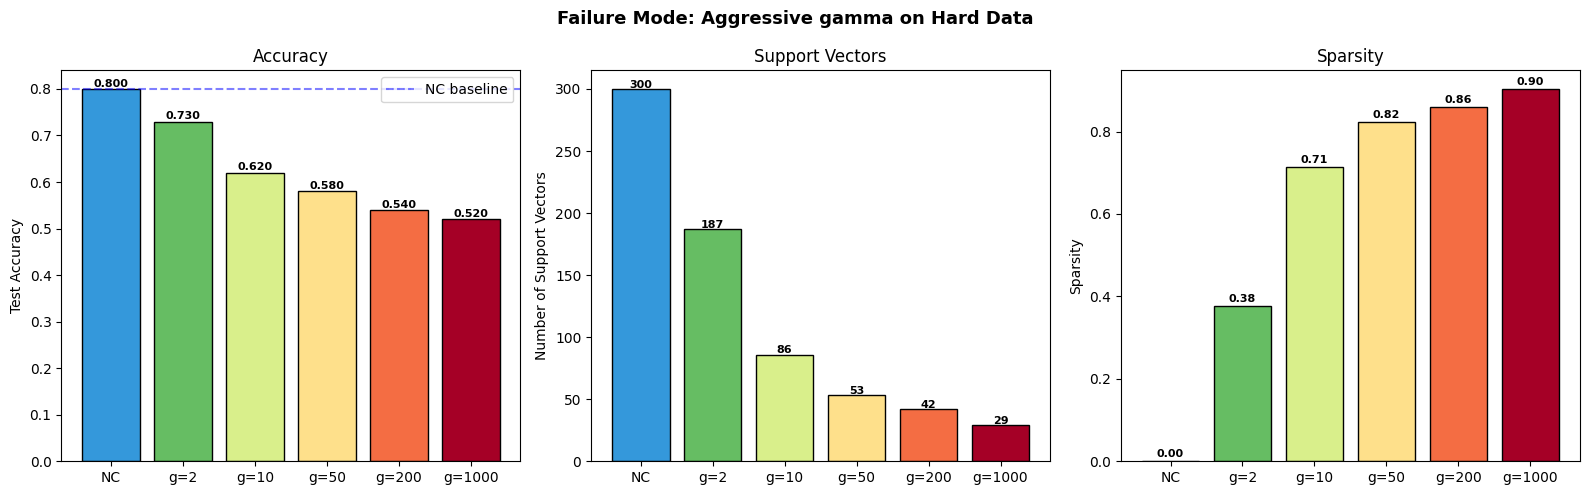

Saved: results/failure_mode_noise.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

labels = ['NC'] + [f'g={g}' for g in gamma_values]
accs = [results['NC'][0]] + [results[f'Aux(g={g})'][0] for g in gamma_values]
svs = [results['NC'][1]] + [results[f'Aux(g={g})'][1] for g in gamma_values]
sparsities = [results['NC'][2]] + [results[f'Aux(g={g})'][2] for g in gamma_values]

cmap = plt.cm.RdYlGn_r
colors = [cmap(i / (len(labels) - 1)) for i in range(len(labels))]
colors[0] = '#3498db'

axes[0].bar(labels, accs, color=colors, edgecolor='black')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Accuracy')
axes[0].axhline(y=nc_acc, color='blue', linestyle='--', alpha=0.5, label='NC baseline')
axes[0].legend()
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

axes[1].bar(labels, svs, color=colors, edgecolor='black')
axes[1].set_ylabel('Number of Support Vectors')
axes[1].set_title('Support Vectors')
for i, v in enumerate(svs):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=8, fontweight='bold')

axes[2].bar(labels, sparsities, color=colors, edgecolor='black')
axes[2].set_ylabel('Sparsity')
axes[2].set_title('Sparsity')
for i, v in enumerate(sparsities):
    axes[2].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Failure Mode: Aggressive gamma on Hard Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/failure_mode_noise.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/failure_mode_noise.png')

## Why the Method Fails in This Scenario

The results clearly show a **monotonic accuracy collapse** as $\gamma$ increases on this hard dataset. At moderate $\gamma$ (2-10), the Auxiliary algorithm maintains accuracy comparable to NC while achieving meaningful sparsity. But at $\gamma = 200$ and beyond, accuracy drops sharply below NC, while sparsity approaches 100%. The method is effectively learning from almost no examples.

The mechanism is straightforward: with large $\gamma$, the auxiliary function $h(z) = \ln(\gamma + e^{-z})$ is much larger than $\ell(z) = \ln(1 + e^{-z})$ for all but the most extreme misclassifications. The sampling probability $p_t = \ell/h$ therefore collapses toward zero for most training examples. The Bernoulli gate blocks nearly all updates, and the classifier sees too few examples to learn the decision boundary — especially on this dataset where the classes overlap (class_sep=0.5) and informative features are limited.

This connects directly to **Assumption 3** (Task 1.2): the auxiliary function dominance condition $h(z) \ge \ell(z)$ is satisfied, but the *tightness* of this bound matters. Theorem 4 shows that the generalisation bound depends on $\min_f \mathbb{E}[h(yf(x))]$, not $\min_f \mathbb{E}[\ell(yf(x))]$. When $h \gg \ell$ (large $\gamma$), this bound is much looser than the NC bound, and in practice the algorithm converges to a poor solution. The paper's Figure 4 hints at this with the accuracy curve declining at extreme $\gamma - 1$ values, but on their easier datasets (mushrooms, ijcnn1) the effect is mild. On harder data with overlapping classes, the failure is dramatic.

## Suggested Modification

A concrete modification would be to introduce an **adaptive $\gamma$ schedule** that starts with a large $\gamma$ (aggressive skipping) early in training when most examples are uninformative, and gradually decreases $\gamma$ toward 1 as training progresses and the remaining examples become more informative. This would combine the early-stage efficiency of large $\gamma$ with the late-stage accuracy of small $\gamma$, automatically adapting to the dataset difficulty.